In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata

In [4]:
file_path_header = 'results/tasks/experiment_results_task'

rows = []
for i in range(16):
    num_zeros = 4 - len(str(i))
    s = '0' * num_zeros + str(i)

    file_path = f'{file_path_header}_{s}.jsonl'
    for line in open(file_path):
        if line.strip():
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
df

,task_id,total_tasks,combo_index,beta,alpha,rho,strength,kappa,tau,cov_type,...,mean_mse,std_mse,mean_e_TF,std_e_TF,mean_e_ICL,std_e_ICL,mean_e_IDG,std_e_IDG,mean_diff,std_diff
0,0,16,0,0.0,2.350000,0.5,0.0,0.5,2.0,identity,...,2.507656,0.038988,2.521042,0.018671,2.521042,0.018671,1.455562,0.011211,0.0,0.0
1,0,16,1,0.0,2.862867,0.5,0.0,0.5,2.0,identity,...,2.568000,0.039947,2.563843,0.030856,2.563843,0.030856,1.398694,0.008564,0.0,0.0
2,0,16,2,0.0,3.487662,0.5,0.0,0.5,2.0,identity,...,2.648558,0.049209,2.632704,0.030074,2.632704,0.030074,1.340593,0.010867,0.0,0.0
3,0,16,3,0.0,4.248814,0.5,0.0,0.5,2.0,identity,...,2.706124,0.037754,2.726523,0.025859,2.726523,0.025859,1.297164,0.010135,0.0,0.0
4,0,16,4,0.0,5.176080,0.5,0.0,0.5,2.0,identity,...,2.870852,0.070606,2.865099,0.044412,2.865099,0.044412,1.250339,0.012612,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,15,16,195,1.0,45.401157,0.5,0.0,0.5,2.0,identity,...,1.048113,0.008638,1.046758,0.007554,9.731946,0.181762,1.046758,0.007554,0.0,0.0
282,15,16,196,1.0,55.309558,0.5,0.0,0.5,2.0,identity,...,1.038148,0.010447,1.040714,0.006558,11.538809,0.175687,1.040714,0.006558,0.0,0.0
283,15,16,197,1.0,67.380381,0.5,0.0,0.5,2.0,identity,...,1.040281,0.010721,1.039434,0.008087,13.840904,0.161541,1.039434,0.008087,0.0,0.0
284,15,16,198,1.0,82.085553,0.5,0.0,0.5,2.0,identity,...,1.029636,0.010540,1.030831,0.008066,16.182109,0.232389,1.030831,0.008066,0.0,0.0


In [63]:
df.to_csv('saved_processed.csv')

In [30]:
def contour_heatmap(df, metric, resolution=200):
    alphas = sorted(df['alpha'].unique())
    alphas = [a for a in alphas if a >= 2.0 and a <= 101]

    sub = df[(df['alpha'].isin(alphas))]

    x = sub['alpha'].values
    y = sub['beta'].values
    z = sub[metric].values

    xi = np.linspace(x.min(), x.max(), resolution)
    yi = np.linspace(y.min(), y.max(), resolution)
    xi, yi = np.meshgrid(xi, yi)

    zi = griddata((x, y), z, (xi, yi), method='linear')

    print('raw min/max', z.min(), z.max())

    plt.figure(figsize=(8, 5))

    plt.contourf(xi, yi, zi, levels=50)

    plt.colorbar(label=r'$e_{TF}$')
    plt.xlabel(r'$\alpha=\ell/d$')
    plt.ylabel(r'$\beta$')

    plt.savefig('figs/heatmap_alpha_beta.png')

    plt.show()

raw min/max 1.0308314561843872 19.264778900146485


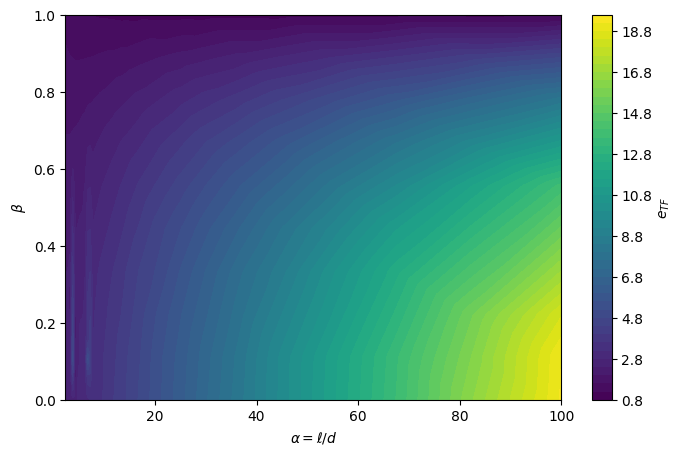

In [31]:
contour_heatmap(df, metric='mean_e_TF')

In [ ]:
def plot_error_curves(
    df: pd.DataFrame,
    betas: list,
    show_e_TF: bool = True,
    ncols: int = 3,
):
    def pooled_std(s):
        return np.sqrt((s ** 2).mean())
 
    agg = (
        df.groupby(["beta", "alpha"], sort=True)
        .agg(
            mean_mse=("mean_mse", "mean"),     std_mse=("std_mse", pooled_std),
            mean_e_TF=("mean_e_TF", "mean"),   std_e_TF=("std_e_TF", pooled_std),
            mean_e_ICL=("mean_e_ICL", "mean"), std_e_ICL=("std_e_ICL", pooled_std),
            mean_e_IDG=("mean_e_IDG", "mean"), std_e_IDG=("std_e_IDG", pooled_std),
        )
        .reset_index()
    )
 
    available = np.sort(agg["beta"].unique())
    matched = [available[np.argmin(np.abs(available - b))] for b in betas]
 
    nrows = int(np.ceil(len(matched) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
 
    for i, beta_val in enumerate(matched):
        ax = axes[i // ncols][i % ncols]
        p = agg[np.isclose(agg["beta"], beta_val)].sort_values("alpha")
        a = p["alpha"].values
 
        ax.errorbar(a, p["mean_mse"],   yerr=p["std_mse"],   label="MSE",                fmt="-o",  markersize=3, capsize=2)
        ax.errorbar(a, p["mean_e_ICL"], yerr=p["std_e_ICL"], label=r"$e_\mathrm{ICL}$",  fmt="-s",  markersize=3, capsize=2)
        ax.errorbar(a, p["mean_e_IDG"], yerr=p["std_e_IDG"], label=r"$e_\mathrm{IDG}$",  fmt="-^",  markersize=3, capsize=2)
        if show_e_TF:
            ax.errorbar(a, p["mean_e_TF"], yerr=p["std_e_TF"], label=r"$e_\mathrm{TF}$",
                        fmt="--x", markersize=3, capsize=2, color="black")
 
        ax.set_xscale("log")
        ax.set_title(rf"$\beta = {beta_val:.3g}$")
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel("Error")
        ax.legend(fontsize=8, frameon=False)
        ax.grid(alpha=0.3)
 
    for i in range(len(matched), nrows * ncols):
        axes[i // ncols][i % ncols].set_visible(False)
 
    plt.tight_layout()
    plt.show()

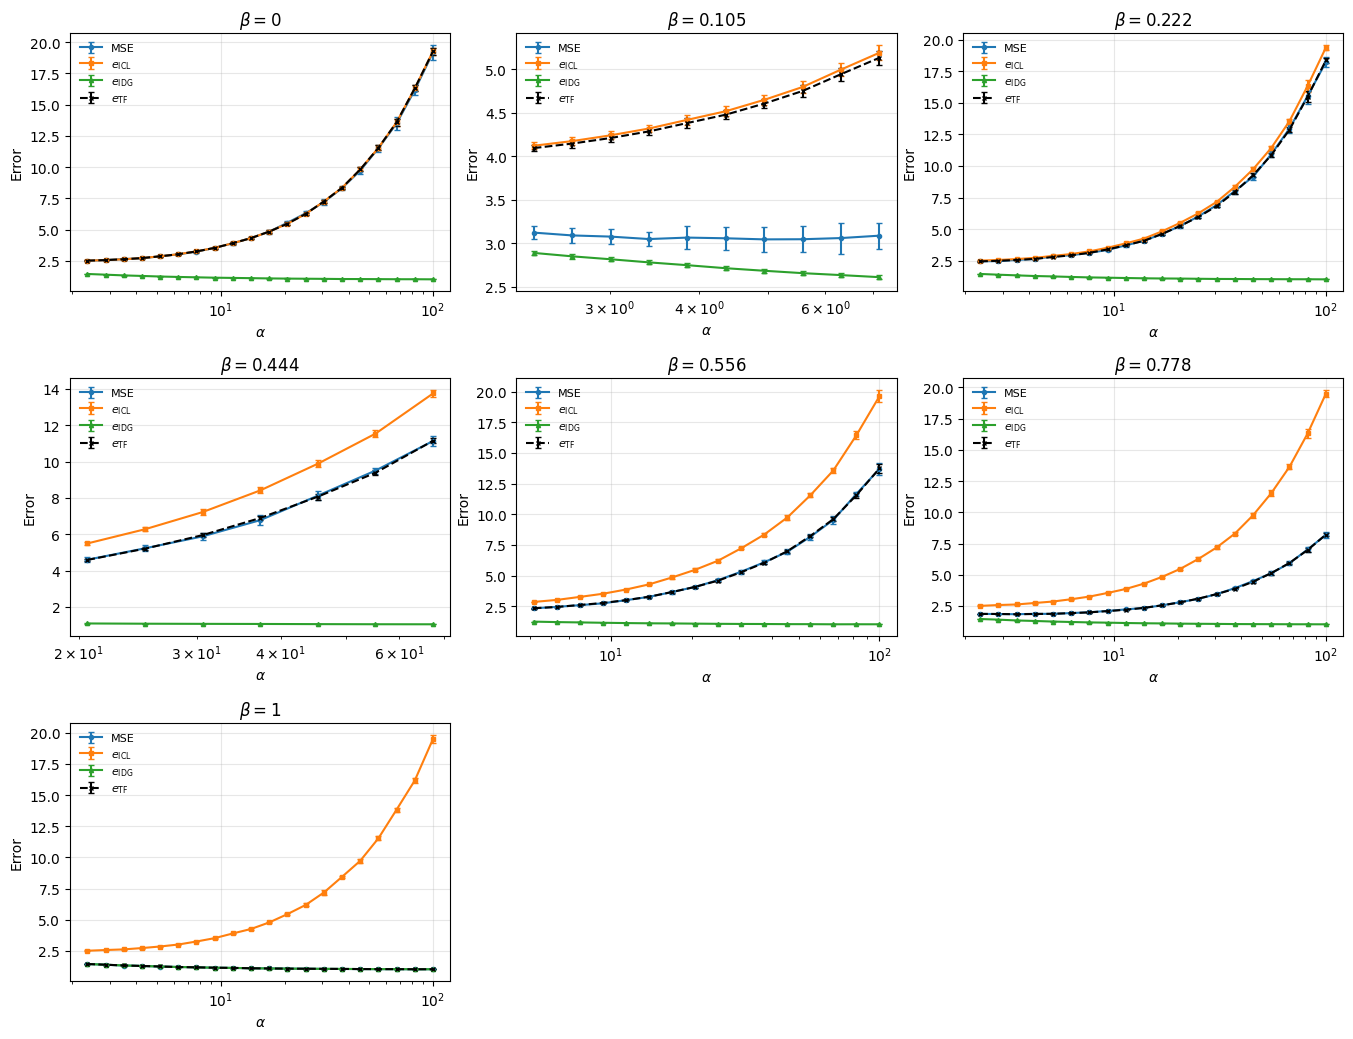

In [ ]:
plot_error_curves(df, betas=[0.0, 0.11, 0.33, 0.55, 0.8, 1.0])